In [19]:
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from rasterio.enums import Resampling
from skimage.segmentation import slic, felzenszwalb, mark_boundaries

In [20]:
# path setup
data_dir = Path(r'C:/Users/momawlod.stu/OneDrive - UBC/Desktop/random stuff/Data')

rgb_path = data_dir / 'MKRF_Aerial_Photo.tif'
chm_path = data_dir / 'chm_mkrf.tif'

In [21]:
#reading the rgb and chm
with rasterio.open(rgb_path) as src:
    red   = src.read(1).astype(float)
    green = src.read(2).astype(float)
    blue  = src.read(3).astype(float) 
    ref_shape = src.shape

with rasterio.open(chm_path) as src:
    chm = src.read(
        1,
        out_shape=ref_shape,
        resampling=Resampling.bilinear
    ).astype(float)

In [22]:
#grvi
grvi = (green - red) / (green + red)

In [42]:
#normalization
def normalize(arr):
    mn, mx = np.nanpercentile(arr, 2), np.nanpercentile(arr, 98)
    return np.clip((arr - mn) / (mx - mn + 1e-10), 0, 1)


#stacking features into multichannel image
img_stack = np.dstack([normalize(chm), normalize(grvi)])  # shape (rows, cols, 2)


#segment image into superpixels with tunable compactness
# segments = slic(
#     img_stack,
#     n_segments=30000,
#     compactness=0.08, #low vlaues mean more irrgular shapes
#     sigma=1, #smoothin
#     channel_axis=-1,
#     start_label=1
# )



#segment image into natural objects based on pixel similarity (height + vegetation)
segments = felzenszwalb(
    img_stack,
    scale=180, # the higher the larger segments are
    sigma=0.5, #moothing
    min_size=50  #minimum segment size
)

In [43]:


#build a feature table. one row per segment
labels = np.unique(segments)
features = []

for seg_id in labels:
    mask = segments == seg_id
    features.append({
        "segment_id": seg_id,
        "mean_chm":  np.nanmean(chm[mask]),
        "mean_grvi": np.nanmean(grvi[mask]),
        "pixel_count": mask.sum()
    })

#convert to pd dataframe
feat_df = pd.DataFrame(features)

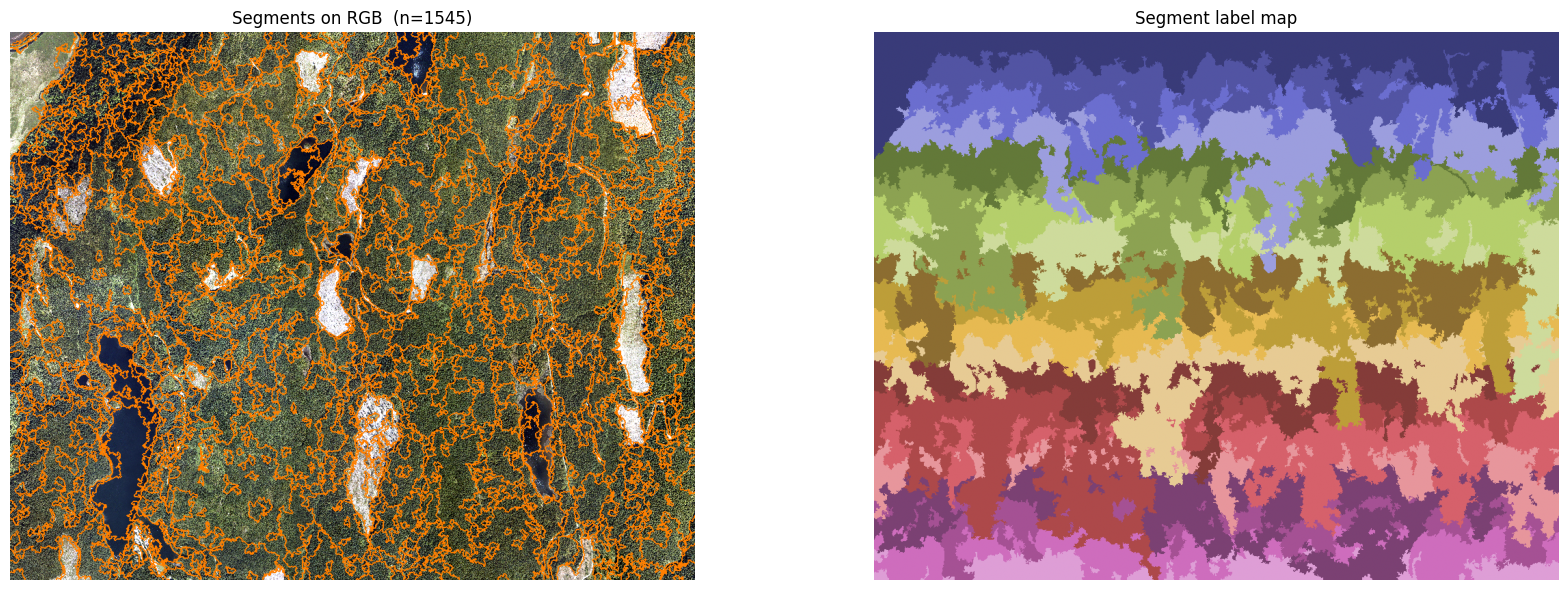

In [44]:
#plotting
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

#rbg setup
rgb_display = np.dstack([normalize(red), normalize(green), normalize(blue)])

axes[0].imshow(mark_boundaries(rgb_display, segments, color=(1, 0.5, 0)))
axes[0].set_title(f"Segments on RGB  (n={segments.max()})")
axes[0].axis("off")

axes[1].imshow(segments, cmap="tab20b")  
axes[1].set_title("Segment label map")
axes[1].axis("off")

plt.tight_layout()
plt.show()